# 02 · Baselines: IDW, ordinary kriging and GMZ on held-out storms

The proposal measures its learned map against three model-driven baselines, on the same held-out
events, with one metric table (its Table 1): RMSE, MAE, Pearson correlation per time step and
pooled, cumulative event error, POD / FAR / CSI at a threshold, and the error at independent
gauges. This notebook produces that table for the baselines; a project's model is scored by the
same call (`core.maps.map_skill.skill_table`).

| baseline | what it does with a link | code |
|---|---|---|
| IDW | a point at the path midpoint; inverse-distance weights, power 2, within 10 km | `core.maps.idw.idw_map` |
| OK | a point at the midpoint; ordinary kriging, spherical variogram whose shape is fitted to the *training* radar | `learned_2d.baselines` (pykrige) |
| GMZ | virtual gauges along the path, corrected so each link keeps its own average (Goldshtein, Messer & Zinevich, 2009) | `core.maps.gmz.gmz_map` |

**Scoring rules.** Hourly totals (mm). Against the radar: cells within 2 km of a link only (the
proposal's "mask unobservable cells rather than extrapolating into them"), and only the cell-hours
every map has, so all rows share one sample. At gauges: the 10 municipal gauges and the SMHI gauge,
which no method uses, in the cell that contains each. Wet = 0.1 mm in the hour unless stated.

**Runtime:** under a minute (needs the dataset of notebook 01).

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")    # PyTorch and other OpenMP users in one process

import sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "projects/maps/learned_2d/src"))

from core.data_paths import OUTPUTS
from core.maps import learning as ml

CACHE = OUTPUTS / "_learned_2d"          # generated files, not tracked
SPLIT_COLORS = {"train": "#3b6fb6", "val": "#e08a2e", "test": "#c03b3b"}
plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 10})
T0 = time.time()
from core.maps import map_skill as sk
from learned_2d.baselines import baseline_maps, fit_variogram

In [2]:
ds = ml.build_network_dataset("openmrg", cache_dir=CACHE)     # built by notebook 01, read from the cache
test = ds.sel(time=ds.split == "test")
mask = ds.observable.values.astype(bool)
check = test.gauges.sel(station=test.station_set.isin(["city", "smhi"]))    # independent check gauges
print(f"test: {test.sizes['time']} hours of {len(set(test.event_id.values))} events; "
      f"{int(mask.sum())} scored cells; {check.sizes['station']} check gauges")

test: 102 hours of 5 events; 852 scored cells; 11 check gauges


## 1. The three baseline maps on the test events

The kriging variogram is fitted to the radar fields of the training events only (shape: range
and nugget share; the sill is each hour's link variance and does not change the weights).

In [3]:
variogram = fit_variogram(ds, "train")
print({k: round(v, 3) if isinstance(v, float) else v for k, v in variogram.items()})
t = time.time()
maps = baseline_maps(test, variogram)
print(f"three maps x {test.sizes['time']} hours in {time.time() - t:.0f} s")

{'sill': 1.0, 'range': 59371.258, 'nugget': 0.143, 'fitted': True, 'hours': 166}


three maps x 102 hours in 13 s


## 2. The proposal's metric table

Against the radar on the scored cells, and at the independent gauges. The radar itself is not
ground truth: the last cell scores it at the same gauges, which tells how far the target can be
trusted.

In [4]:
table = sk.skill_table(maps, test.target, event=test.event_id, mask=mask, gauges=check, threshold=0.1)
pd.set_option("display.precision", 3)
table

,n,rmse,mae,bias,pcc,pcc_step,event_bias,event_abs_rel_error,pod,far,csi,gauge_n,gauge_rmse,gauge_mae,gauge_bias,gauge_pcc
method,,,,,,,,,,,,,,,,
idw,86659,1.032,0.460,-0.252,0.683,0.372,-5.118,0.592,0.414,0.169,0.382,1122,0.736,0.317,-0.186,0.831
ok,86659,1.039,0.463,-0.248,0.678,0.377,-5.047,0.586,0.419,0.164,0.387,1122,0.879,0.372,-0.155,0.775
gmz,86659,1.034,0.461,-0.248,0.682,0.365,-5.046,0.582,0.411,0.177,0.378,1122,0.730,0.313,-0.203,0.834


In [5]:
radar_at_gauges = sk.gauge_point_error(test.target, check)
print("radar at the same gauges: " + ", ".join(f"{k} {radar_at_gauges[k]:.3f}" for k in ("n", "rmse", "mae", "bias", "corr")))

radar at the same gauges: n 1122.000, rmse 0.874, mae 0.380, bias 0.019, corr 0.733


## 3. Detection at several thresholds, and each event's total

POD (share of wet radar cells the map also calls wet), FAR (share of the map's wet cells the
radar calls dry), CSI (both together). Then the cumulative error per test event: the event total
averaged over the scored cells, map against radar.

In [6]:
joint = np.isfinite(test.target.values) & np.all([np.isfinite(m.values) for m in maps.values()], axis=0)
common = {k: m.where(joint) for k, m in maps.items()}
det = pd.DataFrame([{"method": k, **sk.detection(m, test.target, thr, mask)} for thr in (0.1, 1.0, 5.0)
                    for k, m in common.items()]).set_index(["threshold", "method"])
det

n    pod    far    csi
threshold method                            
0.1       idw     86659  0.414  0.169  0.382
          ok      86659  0.419  0.164  0.387
          gmz     86659  0.411  0.177  0.378
1.0       idw     86659  0.392  0.218  0.353
          ok      86659  0.389  0.227  0.349
          gmz     86659  0.393  0.226  0.353
5.0       idw     86659  0.472  0.436  0.346
          ok      86659  0.474  0.439  0.346
          gmz     86659  0.475  0.427  0.351

In [7]:
totals = pd.concat({k: sk.event_totals(m, test.target, test.event_id, mask) for k, m in common.items()}, axis=1)
totals.xs("total_est", axis=1, level=1).assign(radar=totals[("idw", "total_ref")]).round(2)

,idw,ok,gmz,radar
event,,,,
20150605T17,0.27,0.31,0.37,3.90
20150707T17,11.90,11.79,11.83,15.26
20150725T05,0.94,1.02,1.08,9.87
20150824T07,1.72,1.76,1.79,5.46
20150827T01,21.01,21.32,21.15,26.95


## 4. Maps of one test event

The largest test event: totals over the event (top) and its wettest hour (bottom). Black line:
the scored cells. Every map is empty beyond 10 km of a link.

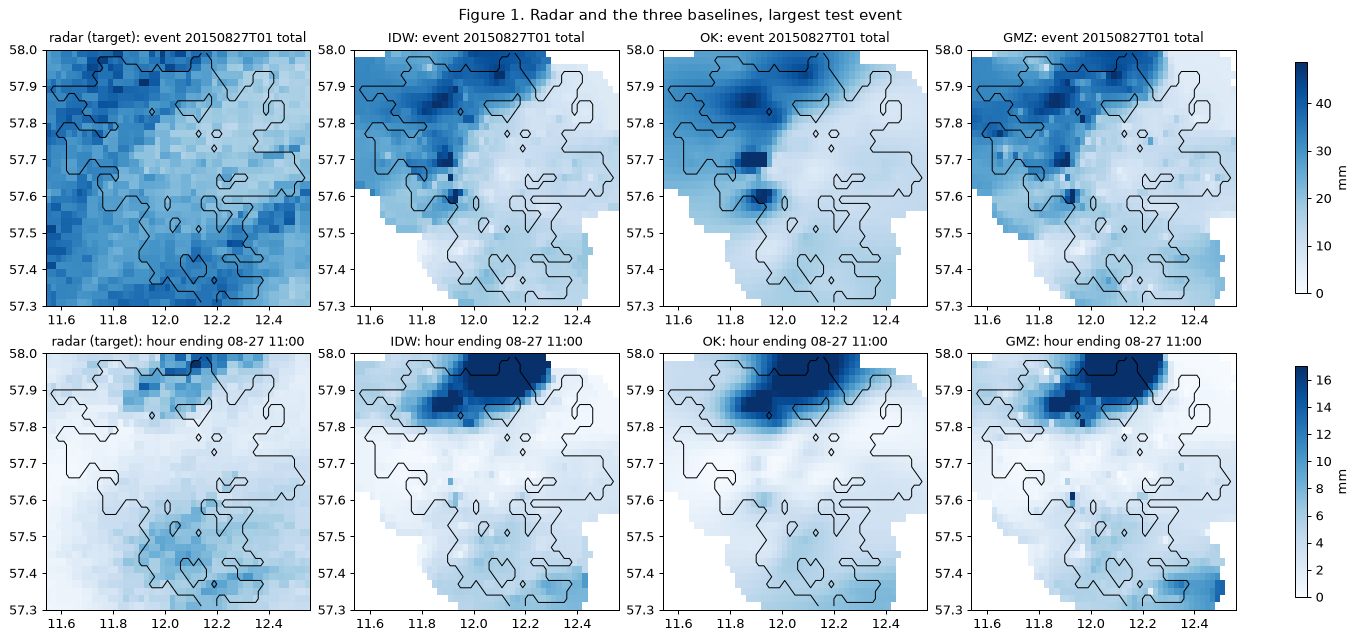

In [8]:
ev = test.event_total_mm.where(test.event_split == "test").idxmax().item()
sel = test.event_id == ev
hour = test.time.values[sel][int(test.target.sel(time=sel).where(test.observable == 1).mean(("lat", "lon")).argmax())]
fields = {"radar (target)": test.target, **{k.upper(): m for k, m in maps.items()}}
fig, axes = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True)
for row, (label, pick) in enumerate([(f"event {ev} total", lambda m: m.sel(time=sel).sum("time", min_count=1)),
                                     (f"hour ending {pd.Timestamp(hour):%m-%d %H:%M}", lambda m: m.sel(time=hour))]):
    vmax = float(pick(test.target).where(test.observable == 1).max())
    for ax, (name, m) in zip(axes[row], fields.items()):
        pm = ax.pcolormesh(test.lon, test.lat, pick(m), cmap="Blues", vmin=0, vmax=vmax, shading="auto")
        ax.contour(test.lon, test.lat, mask, levels=[0.5], colors="k", linewidths=0.8)
        ax.set_title(f"{name}: {label}")
    fig.colorbar(pm, ax=axes[row].tolist(), label="mm", shrink=0.9)
fig.suptitle("Figure 1. Radar and the three baselines, largest test event"); plt.show()

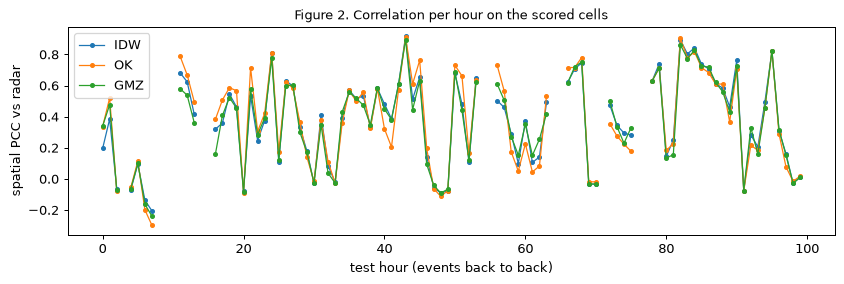

runtime 20 s


In [9]:
fig, ax = plt.subplots(figsize=(11, 3))
for k, m in common.items():
    ax.plot(range(test.sizes["time"]), sk.pcc_per_step(m, test.target, mask).values, marker="o", ms=3, lw=1, label=k.upper())
ax.set(xlabel="test hour (events back to back)", ylabel="spatial PCC vs radar",
       title="Figure 2. Correlation per hour on the scored cells")
ax.legend(); plt.show()
print(f"runtime {time.time() - T0:.0f} s")

## Your method goes here

Score a project's map the same way, on the same hours, cells and gauges:

```python
est = ...  # (time, lat, lon) on test.lat / test.lon / test.time, mm in the hour
sk.skill_table({**maps, "mine": est}, test.target, event=test.event_id, mask=mask, gauges=check)
```

`skill_table` scores every map only where all of them have a value, so adding a map with gaps
shrinks the common sample for every row: compare tables built with the same set of maps.